In [6]:
import numpy as np
import pandas as pd
income = np.array([30,35,40,45,50,55,60,65,22,28,33,38,43,48,53,58]).reshape(-1,1)
purchase = np.array([0,0,0,1,1,1,1,1,0,0,0,0,1,1,1,1])
df=pd.DataFrame({'Monthly income':income.flatten(),'Purchase':purchase})
print('Dataset')
print('-'*35)
print(df)

Dataset
-----------------------------------
    Monthly income  Purchase
0               30         0
1               35         0
2               40         0
3               45         1
4               50         1
5               55         1
6               60         1
7               65         1
8               22         0
9               28         0
10              33         0
11              38         0
12              43         1
13              48         1
14              53         1
15              58         1


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(income,purchase,test_size=0.3,random_state=42)
print('Monthly Income: ',len(X_train))
print('Purchase: ',len(X_test))

Monthly Income:  11
Purchase:  5


In [32]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(income,purchase)

new_income=np.array([[105]])
prediction=model.predict(new_income)
probability=model.predict_proba(new_income)
print('Income:',new_income[0][0])

Income: 105


In [33]:
if prediction[0]==1:
    print("Prediction: Customer Will Purchase")
else:
    print("Prediction: Customer Will Not Purchase")

Prediction: Customer Will Purchase


In [34]:
print("Probability (No, Yes):", probability)
print("Accuracy:", model.score(income,purchase))

Probability (No, Yes): [[0. 1.]]
Accuracy: 1.0


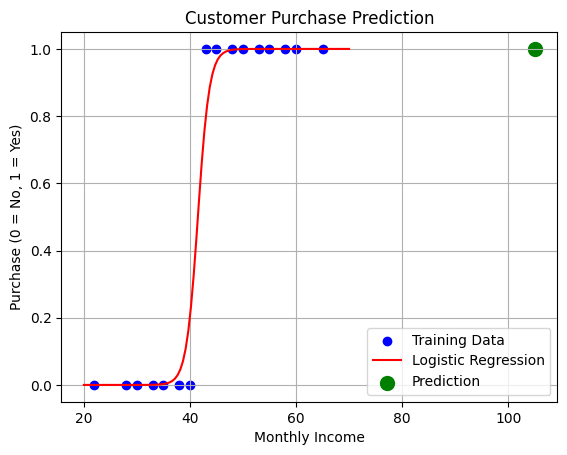

In [36]:
import matplotlib.pyplot as plt
x = np.linspace(20, 70, 100).reshape(-1, 1)
y_prob = model.predict_proba(x)[:, 1]

plt.scatter(income, purchase, color="blue", label="Training Data")
plt.plot(x, y_prob, color="red", label="Logistic Regression")
plt.scatter(new_income, prediction, color="green", s=100, label="Prediction")

plt.xlabel("Monthly Income")
plt.ylabel("Purchase (0 = No, 1 = Yes)")
plt.title("Customer Purchase Prediction")
plt.legend()
plt.grid(True)
plt.show()